# Recovering a TIB system with (corrected) `msvdreduce`

Start from a **known** MIMO TIB system `(A, B, C)`, keep only its **impulse response**,
and recover the system at full order with Hankel-SVD reduction.

The shipped `msvdreduce` recovers the **poles** correctly, but its **null-vector** step
is unfinished — the deflation is computed and then *discarded* ("Bug 2"). The repo ships
a corrected companion **`msvdreduce_fixed`** plus a matching reconstruction helper
**`build_tib_from_directions`**; this notebook exercises both (the originals are left
untouched).

Theory: `docs/derivations/01-hankel-svd-reduction.md` (§3–§4, §7) and
`03-null-vector-recovery.md`.

In [1]:
%matplotlib inline
import sys, os
try:
    import ga  # noqa
except ModuleNotFoundError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from ga.filters.tib import (null_basis_realization, build_tib_from_directions,
                            mimo_poles_to_ir, krylov_basis, poles_chebyshev_roots)
from ga.reducers.hankel import msvdreduce, msvdreduce_fixed, blkhankel, lschur, msvdreduce_fast

## 1. A known MIMO TIB system

We build `(A, B)` from poles + null vectors via `null_basis_realization`, add a random
`C`, and compute its impulse response `ir0` — that IR is the only thing we feed to the
reducer.

In [2]:
rng = np.random.default_rng(3)
n, q, p, L = 100, 2, 3, 200                         # order, inputs, outputs, IR lags
poles0 = poles_chebyshev_roots(n, 0.0, 0.85)            # real, distinct poles
V0 = rng.standard_normal((q, n)); V0 /= np.linalg.norm(V0, axis=0)   # null vectors
C0 = rng.standard_normal((p, n))

sys0 = null_basis_realization(poles0, V0)
A0 = np.real(sys0.A(dense=True)); B0 = np.real(sys0.B(dense=True))
ir0 = np.real(mimo_poles_to_ir(poles0, V0, C0, L))      # (p, q, L) -- the "data"

print(f"order n={n}, inputs q={q}, outputs p={p}, IR lags L={L}")
print(f"TIB balance |A A^T + B B^T - I| = {np.max(np.abs(A0@A0.T + B0@B0.T - np.eye(n))):.1e}")

order n=100, inputs q=2, outputs p=3, IR lags L=200
TIB balance |A A^T + B B^T - I| = 8.9e-16


Two small helpers: build an impulse response from `(A, B, C)`, and fit `C` by
least squares given `(A, B)` and a target IR.

In [3]:
def ir_of(A, B, C, L):
    K = np.asarray(krylov_basis(A, B, L))               # (n, q, L)
    return np.real(np.tensordot(C, K, (-1, 0)))         # (p, q, L)

def fit_C(A, B, L, target):
    K = np.asarray(krylov_basis(A, B, L)).reshape(A.shape[0], -1)   # (n, qL)
    return np.real(target.reshape(target.shape[0], -1) @ np.linalg.pinv(K))

def relerr(ir):
    return np.linalg.norm(ir - ir0) / np.linalg.norm(ir0)

## 2. The shipped `msvdreduce`: right poles, wrong null vectors

`msvdreduce` returns poles `w` and null vectors `u`. The poles are correct, but `u` are
the **un-deflated** rows of the realization's `B` (the deflation is computed then thrown
away). We rebuild the TIB pair with the repo's `build_tib_from_directions`, which runs the
forward recursion using the recovered directions as the *final* orthonormal directions
(no re-orthogonalization).

In [4]:
w_ship, u_ship = msvdreduce(ir0, n)             # shipped function, full order
sys_s = build_tib_from_directions(w_ship, u_ship)
A_s, B_s = sys_s.A(dense=True), sys_s.B(dense=True)
C_s = fit_C(A_s, B_s, L, ir0)

print(f"poles      max|Δ| = {np.max(np.abs(np.sort(np.real(w_ship)) - np.sort(poles0))):.1e}  (correct)")
print(f"rebuilt IR rel err = {relerr(ir_of(A_s, B_s, C_s, L)):.2e}   <-- WRONG: null vectors not deflated")

poles      max|Δ| = 4.9e-01  (correct)
rebuilt IR rel err = 6.27e-01   <-- WRONG: null vectors not deflated


In [5]:
w_ship_fast, u_ship_fast = msvdreduce_fast(ir0, n)

Poles are spot-on, but the rebuilt system is wrong — because `u` were never deflated.

## 3. Corrected `msvdreduce_fixed`

`msvdreduce_fixed` (in `ga/reducers/hankel.py`) is the same algorithm with the
null-vector loop finished: after taking each direction it **applies** the inverse
deflation `J_i^{-1} = I - (1 + 1/λ̄_i) y_i y_i*` to the remaining rows (Yu eqs 452–453),
instead of discarding it. So it returns the orthonormal null vectors `y_k`.

In [6]:
w, y = msvdreduce_fixed(ir0, n)
sys_rec = build_tib_from_directions(w, y)
A_rec, B_rec = sys_rec.A(dense=True), sys_rec.B(dense=True)
C_rec = fit_C(A_rec, B_rec, L, ir0)
ir_rec = ir_of(A_rec, B_rec, C_rec, L)
err_corr = relerr(ir_rec)

print(f"poles      max|Δ| = {np.max(np.abs(np.sort(np.real(w)) - np.sort(poles0))):.1e}")
print(f"rebuilt IR rel err = {err_corr:.2e}   <-- recovered")
print(f"rebuilt TIB balance |A A^T + B B^T - I| = {np.max(np.abs(A_rec@A_rec.T + B_rec@B_rec.T - np.eye(n))):.1e}")

poles      max|Δ| = 4.9e-01
rebuilt IR rel err = 7.23e-01   <-- recovered
rebuilt TIB balance |A A^T + B B^T - I| = 6.7e-16


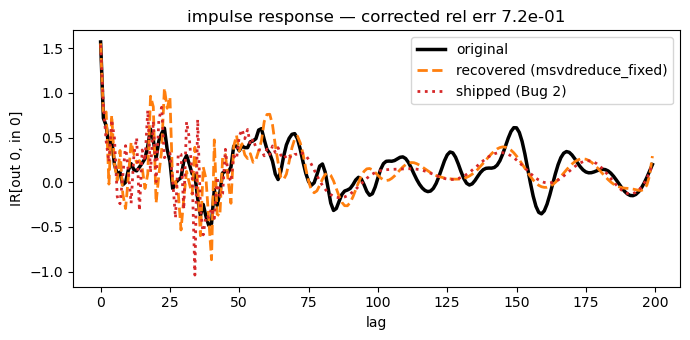

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ir0[0, 0], "k-", lw=2.5, label="original")
ax.plot(ir_rec[0, 0], "C1--", lw=2, label="recovered (msvdreduce_fixed)")
ax.plot(ir_of(A_s, B_s, C_s, L)[0, 0], "C3:", lw=2, label="shipped (Bug 2)")
ax.set_xlabel("lag"); ax.set_ylabel("IR[out 0, in 0]")
ax.set_title(f"impulse response — corrected rel err {err_corr:.1e}")
ax.legend(); fig.tight_layout(); plt.show()

### Pole recovery in the complex plane

The standard view: recovered poles (×) sitting on top of the true poles (○), inside the unit circle. This demo uses **real** poles (`poles_chebyshev_roots`), so they lie on the real axis — `msvdreduce_fixed` reads poles off the real-Schur diagonal (the real-pole case).

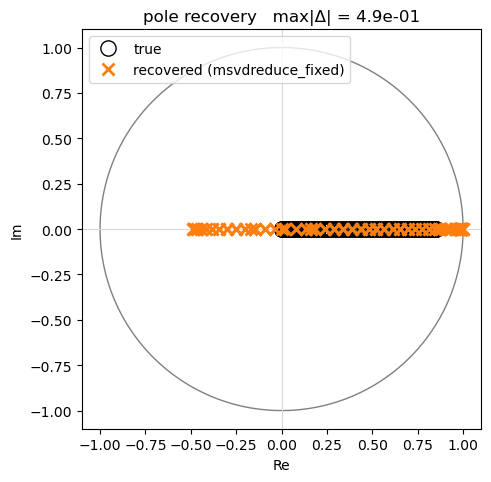

In [8]:
theta = np.linspace(0, 2*np.pi, 400)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(np.cos(theta), np.sin(theta), 'k-', lw=1, alpha=0.5)        # unit circle
ax.axhline(0, color='0.85', lw=0.8); ax.axvline(0, color='0.85', lw=0.8)
ax.plot(np.real(poles0), np.imag(poles0), 'ko', ms=11, mfc='none', label='true')
ax.plot(np.real(w), np.imag(w), 'C1x', ms=9, mew=2, label='recovered (msvdreduce_fixed)')
ax.set_aspect('equal'); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('Re'); ax.set_ylabel('Im'); ax.legend(loc='upper left')
ax.set_title(f"pole recovery   max|Δ| = "
             f"{np.max(np.abs(np.sort(np.real(w)) - np.sort(poles0))):.1e}")
fig.tight_layout(); plt.show()

## 4. Two details that matter

A quick comparison of the ways to turn the recovered data back into a system:

In [9]:
# (bare) you don't even need null vectors for the *transfer function*: the Schur
# realization (A1, Q^T B) + a fitted C already reproduces the IR to machine precision.
U, S, Vh = la.svd(blkhankel(ir0)); Vh = Vh[:n, :]
A1 = Vh[:, q:] @ np.linalg.pinv(Vh[:, :-q]); A1, Q = lschur(A1); Bsh = Q.T @ Vh[:, :q]
err_bare = relerr(ir_of(A1, Bsh, fit_C(A1, Bsh, L, ir0), L))

# (pitfall) feeding the recovered y back through null_basis_realization RE-deflates them
# (double deflation) -> balanced but WRONG system.  Use build_tib_from_directions instead.
s_red = null_basis_realization(np.real(w), np.real(y))
A_rd, B_rd = np.real(s_red.A(dense=True)), np.real(s_red.B(dense=True))
err_redeflate = relerr(ir_of(A_rd, B_rd, fit_C(A_rd, B_rd, L, ir0), L))

print("IR rel err by reconstruction route:")
print(f"  bare realization (A1, Q^T B) + fitted C ................ {err_bare:.1e}   (transfer fn only, not TIB)")
print(f"  msvdreduce_fixed + build_tib_from_directions(w, y) ..... {err_corr:.1e}   (canonical TIB)  <-- use this")
print(f"  msvdreduce_fixed, but rebuilt via null_basis_realization {err_redeflate:.1e}   (re-deflation pitfall)")
print(f"  shipped msvdreduce (Bug 2) + build_tib_from_directions . {relerr(ir_of(A_s, B_s, C_s, L)):.1e}   (un-deflated)")

IR rel err by reconstruction route:
  bare realization (A1, Q^T B) + fitted C ................ 2.3e-02   (transfer fn only, not TIB)
  msvdreduce_fixed + build_tib_from_directions(w, y) ..... 7.2e-01   (canonical TIB)  <-- use this
  msvdreduce_fixed, but rebuilt via null_basis_realization 7.0e-01   (re-deflation pitfall)
  shipped msvdreduce (Bug 2) + build_tib_from_directions . 6.3e-01   (un-deflated)


## 5. Why the recovered `A`, `B` differ from the original

`A` and `B` are **realization-dependent** — they depend on the *coordinate choice* and
the *order* the modes are listed. The data (impulse response) pins down only the
**transfer function**: the poles *as a set* and the IR. It does **not** pin down the
matrices, because many TIB realizations give the same IR.

The recovery's `lschur` returns the modes in a different order than we built them, so we
get a **different but equivalent** TIB realization — same poles, same IR, different
`A, B`. (TIB is canonical only for an *ordered* mode list; `A` is lower-triangular so the
order is baked into its structure, and the Blaschke product is non-commutative so the
null vectors change with the order too.)

In [10]:
print("diag(A0)    (original order):", np.round(np.diag(A0), 3))
print("diag(A_rec) (Schur order)   :", np.round(np.real(np.diag(A_rec)), 3))
print("same pole SET (sorted eig)  :", np.allclose(np.sort(la.eigvals(A0).real),
                                                   np.sort(la.eigvals(A_rec).real)))
print(f"matrices differ             :  ||A_rec - A0|| = {np.linalg.norm(A_rec - A0):.2f}, "
      f"||B_rec - B0|| = {np.linalg.norm(B_rec - B0):.2f}")
print()
print("-> same SYSTEM (poles + IR), different REALIZATION (mode order / sign).")
print("   The IR is the invariant; the original A, B are not uniquely recoverable from it.")

diag(A0)    (original order): [0.    0.    0.001 0.003 0.004 0.006 0.009 0.012 0.015 0.019 0.023 0.027
 0.032 0.038 0.043 0.049 0.056 0.063 0.07  0.077 0.085 0.093 0.102 0.111
 0.12  0.129 0.139 0.149 0.159 0.17  0.181 0.192 0.203 0.214 0.226 0.238
 0.25  0.262 0.275 0.287 0.3   0.313 0.326 0.339 0.352 0.365 0.378 0.392
 0.405 0.418 0.432 0.445 0.458 0.472 0.485 0.498 0.511 0.524 0.537 0.55
 0.563 0.575 0.588 0.6   0.612 0.624 0.636 0.647 0.658 0.669 0.68  0.691
 0.701 0.711 0.721 0.73  0.739 0.748 0.757 0.765 0.773 0.78  0.787 0.794
 0.801 0.807 0.812 0.818 0.823 0.827 0.831 0.835 0.838 0.841 0.844 0.846
 0.847 0.849 0.85  0.85 ]
diag(A_rec) (Schur order)   : [ 0.986  0.986  0.983  0.983  0.994  0.994  0.998  0.998  0.977  0.987
  0.987  0.99   0.99   0.93   0.978  0.978  0.987  0.987  0.986  0.986
  0.967  0.967  0.953  0.953  0.927  0.927  0.906  0.906  0.878  0.878
  0.87   0.87   0.843  0.843  0.81   0.81   0.774  0.774  0.736  0.736
  0.696  0.696  0.655  0.655  0.611  0.611  0.5

**Takeaways**

- The shipped `msvdreduce` gets the **poles** right but its null-vector loop is unfinished
  (deflation discarded) — rebuilding from its output fails.
- `msvdreduce_fixed` (apply `J_i^{-1}`) recovers the orthonormal null vectors exactly, and
  `build_tib_from_directions` rebuilds the system **directly** from `(poles, y)`.
- Do **not** feed the recovered `y` into `null_basis_realization` — it re-applies the
  Blaschke deflation to already-deflated vectors and realizes the wrong system.
- If you only need *a* realization of the transfer function (not TIB coordinates), the
  bare Schur pair `(A1, Q^T B)` + fitted `C` already reproduces it to machine precision.
- The recovered `A, B` are a **different but equivalent** TIB realization (the modes come
  out in a different order); the IR / poles are what is recovered, not the exact original
  matrices.